In [ ]:
import pandas as pd
import numpy as np
import time

1. Download data:

In [ ]:
file_name = 'Longitude_Latitude_data.csv'
df = pd.read_csv(file_name)

2. Extracting coordinates:

In [ ]:
points = df[['latitude', 'longitude']].values[:1000]

3. Euclidean Distance:

In [ ]:
def calculate_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

4. Nearest Neighbor:

In [ ]:
def nearest_neighbor_algorithm(nodes):
    start_time = time.time()
    n = len(nodes)
    visited = [False] * n
    path = [0]
    visited[0] = True
    total_cost = 0

    current_node = 0
    for _ in range(n - 1):
        nearest_node = -1
        min_dist = float('inf')


#Searching for nearest neighbor

        for i in range(n):
            if not visited[i]:
                d = calculate_dist(nodes[current_node], nodes[i])
                if d < min_dist:
                    min_dist = d
                    nearest_node = i

        path.append(nearest_node)
        visited[nearest_node] = True
        total_cost += min_dist
        current_node = nearest_node


#Returning to starting point:

        total_cost += calculate_dist(nodes[current_node], nodes[path[0]])
    end_time = time.time()

    execution_time = (end_time - start_time) * 1000 
    return path, total_cost, execution_time

5. Running the algorithm:

In [ ]:
path, distance, time_taken = nearest_neighbor_algorithm(points)

print(f"--- Results of the Nearest Neighbor algorithm ---")
print(f"Number of points processed: {len(points)}")
print(f"Total distance traveled: {distance:.4f}")
print(f"Execution time: {time_taken:.2f} m/s")

--- Results of the Nearest Neighbor algorithm ---
Number of points processed: 52
Total distance traveled: 3822.0235
Execution time: 21.22 m/s


6. Draw the resulting path:

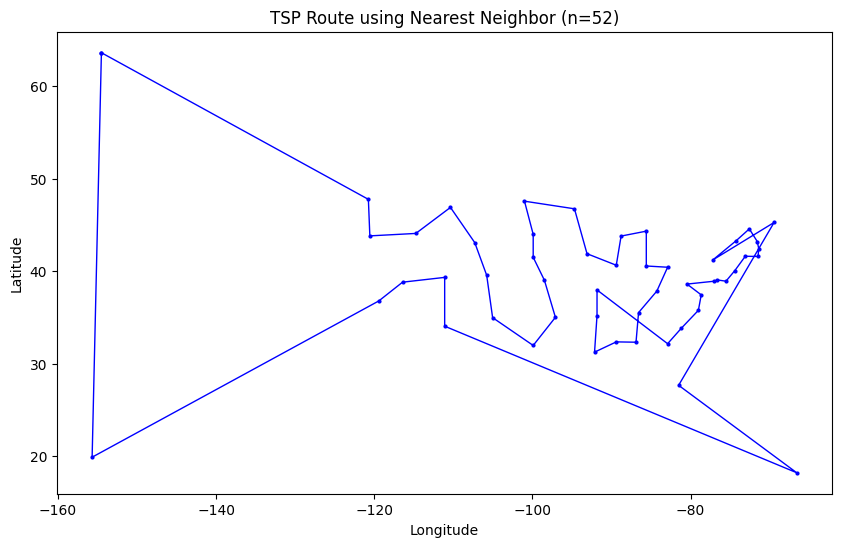

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
path_points = points[path + [path[0]]]
plt.plot(path_points[:, 1], path_points[:, 0], 'b-o', markersize=2, linewidth=1)
plt.title(f"TSP Route using Nearest Neighbor (n={len(points)})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()